![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

# QVM Composite Score + Macro Timing Strategy
## Research Notebook — Signal Validation & Universe Analysis
 
**Author:** Neelkanth Mehta  
**Platform:** QuantConnect LEAN Research Environment  
**Strategy Version:** v3.0 (Two-Sleeve Architecture)
 
---
 
### Overview
 
This notebook validates the three-pillar Quality-Value-Momentum (QVM) composite
scoring model and the IWD-based macro timing overlay before deployment in the
production trading algorithm.
 
The strategy is grounded in six peer-reviewed academic papers published between
1993 and 2017, spanning profitability, value, accruals, and momentum research.
It represents a deliberate departure from the Piotroski F-Score (1976–1996 data),
which shows documented post-publication alpha decay, in favour of factors with
robust empirical performance through the 2015–2025 period.
 
**Full Backtest Period:** January 2015 – December 2025  
**In-Sample (parameter validation):** January 2015 – December 2022  
**Out-of-Sample (attribution):** January 2023 – December 2025  
**Benchmark:** IWD (iShares Russell 1000 Value ETF)
 
---
 
### Academic Foundation
 
| Paper | Factor | Contribution to QVM |
|---|---|---|
| Novy-Marx (2013) | Gross Profitability | Q1 signal |
| Asness, Frazzini & Pedersen (2014) — QMJ | Quality Minus Junk | Q2, Q3 signals |
| Sloan (1996) | Accruals Anomaly | Q3 signal |
| Greenblatt (2005) | Magic Formula (EBIT/EV) | V1 signal |
| O'Shaughnessy (2012) | FCF Yield | V2 signal |
| Jegadeesh & Titman (1993) | Price Momentum | M1 signal |
| Novy-Marx (2015) | Fundamental Momentum | M2, M3 signals |
 
---
 
### Notebook Structure
 
| Cell | Purpose |
|---|---|
| 1 | Environment setup — imports, QuantBook, chart styling |
| 2 | Macro timing construction — IWD 200-SMA and VIX gate |
| 3 | Macro timing visualisation — regime identification |
| 4 | QVM signal analysis — annual cross-sectional scoring |
| 5 | Score distribution and signal hit rate charts |
| 6 | Profit protection architecture rationale |
| 7 | IWD benchmark statistics — hurdle rates |
| 8 | Research summary — confirmed algorithm parameters |

## Cell 1 — Environment Setup
 
We initialise the QuantConnect Research environment via `QuantBook`, which provides
point-in-time access to historical price data, Morningstar fundamental data, and
CBOE volatility data — all free of look-ahead bias.

Chart styling is configured globally using a dark-background palette consistent
with the portfolio presentation aesthetic.

In [2]:
# ================================================================
# CELL 1 -- Imports and QuantBook Initialisation
# ================================================================
 
from AlgorithmImports import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
 
qb = QuantBook()
 
plt.rcParams.update({
    'figure.facecolor': '#1a1f2e',
    'axes.facecolor':   '#222736',
    'axes.edgecolor':   '#3a4155',
    'axes.labelcolor':  '#d8cfc0',
    'xtick.color':      '#7a7060',
    'ytick.color':      '#7a7060',
    'text.color':       '#d8cfc0',
    'grid.color':       '#2d3448',
    'grid.linewidth':   0.5,
    'figure.dpi':       120,
    'font.family':      'monospace',
})
 
GOLD  = '#c9a84c'
GREEN = '#4caf7d'
RED   = '#e05c5c'
BLUE  = '#5b9cf6'
MUTED = '#7a7060'
ORANGE= '#e8a44a'
 
print("QuantBook initialised.")
print("Strategy:        QVM Composite Score + Macro Timing")
print("Research period: 2015-01-01 to 2025-12-31")
print("In-sample:       2015-01-01 to 2022-12-31")
print("Out-of-sample:   2023-01-01 to 2025-12-31")
print("Benchmark:       IWD (iShares Russell 1000 Value ETF)")

QuantBook initialised.
Strategy:        QVM Composite Score + Macro Timing
Research period: 2015-01-01 to 2025-12-31
In-sample:       2015-01-01 to 2022-12-31
Out-of-sample:   2023-01-01 to 2025-12-31
Benchmark:       IWD (iShares Russell 1000 Value ETF)


## Cell 2 — Macro Timing Signals
 
The strategy employs two independent timing signals as a **macro regime gate**.
Both must be active simultaneously for the active equity sleeve to be invested.
When either signal turns negative and remains so for 5 consecutive trading days,
the active sleeve liquidates to cash. The protected sleeve (GLD + BIL) is never
affected by the timing gate.
 
---
 
### Signal 1 — IWD 200-Day Simple Moving Average
 
The primary timing gate uses the **200-day SMA of IWD** (iShares Russell 1000
Value ETF) as a trend filter. IWD is used instead of SPY for two reasons:
 
1. **Style consistency** — the strategy selects from a broad US equity universe
   with quality, value, and momentum characteristics. IWD is a closer proxy for
   the strategy's natural opportunity set than the growth-heavy S&P 500.
 
2. **Benchmark alignment** — IWD is the performance benchmark. Using it as the
   timing instrument means the strategy is defensively positioned specifically when
   the benchmark is trending down — the regime where active value/quality exposure
   is most vulnerable.
 
*Rule:* Invest active sleeve only when IWD price > IWD 200-day SMA.
 
This builds on Faber (2007), who demonstrated that a 10-month SMA timing rule on
the S&P 500 reduced maximum drawdown by over 50% with minimal sacrifice in
long-run returns.
 
---
 
### Signal 2 — VIX Threshold Gate
 
The secondary gate uses the **CBOE VIX** as a volatility regime filter. VIX above
30 historically corresponds to market stress, elevated cross-asset correlations,
and deteriorating liquidity — conditions under which systematic equity strategies
historically underperform.
 
*Rule:* Invest active sleeve only when VIX < 30.
 
In practice, the VIX gate rarely triggers independently of the SMA gate. Its value
is in providing early protection during fast dislocations where prices have not yet
crossed the SMA threshold.
 
---
 
### 5-Day Confirmation Filter
 
To avoid whipsaw exits on brief single-day dips, the defensive exit requires IWD
to remain below its 200-SMA for **5 consecutive trading days** before liquidating
the active sleeve. This meaningfully reduces transaction costs and false exits.

In [ ]:
# ================================================================
# CELL 2 -- Macro Timing Signal: IWD 200-SMA + VIX
# ================================================================
 
print("\n--- MACRO TIMING ANALYSIS ---")
 
iwd     = qb.AddEquity("IWD", Resolution.Daily).Symbol
vix_sym = qb.AddData(CBOE, "VIX", Resolution.Daily).Symbol
 
start = datetime(2014, 1, 1)
end   = datetime(2025, 12, 31)
 
iwd_hist  = qb.History(iwd,     start, end, Resolution.Daily)
iwd_close = iwd_hist['close'].droplevel(0)
iwd_sma   = iwd_close.rolling(200).mean()
iwd_above = (iwd_close > iwd_sma).astype(int)
 
print(f"IWD data:            {len(iwd_close)} trading days")
print(f"IWD above 200-SMA:   {iwd_above.mean()*100:.1f}% of days")
 
try:
    vix_hist  = qb.History(vix_sym, start, end, Resolution.Daily)
    vix_close = vix_hist['close'].droplevel(0)
    vix_low   = (vix_close < 30).astype(int)
    combined  = iwd_above & vix_low.reindex(iwd_above.index).fillna(1).astype(int)
    print(f"VIX < 30:            {vix_low.mean()*100:.1f}% of days")
    print(f"Both signals active: {combined.mean()*100:.1f}% of days")
    vix_ok = True
except Exception as e:
    print(f"VIX unavailable ({e}) -- using IWD SMA only")
    vix_close = pd.Series(dtype=float)
    combined  = iwd_above
    vix_ok    = False


--- MACRO TIMING ANALYSIS ---
IWD data:            3017 trading days
IWD above 200-SMA:   73.3% of days
VIX < 30:            94.8% of days
Both signals active: 73.3% of days


## Cell 3 — Macro Timing Visualisation
 
The chart plots IWD price against its 200-day SMA, with green shading indicating
investable periods (IWD above SMA and VIX below 30).
 
**Key defensive episodes visible:**
 
- **Q4 2018** — Fed-driven selloff. IWD crosses below SMA; strategy exits before
  worst of the ~14% drawdown.
- **March 2020** — COVID crash. Sharp IWD decline; active sleeve exits early.
  Protected sleeve (GLD/BIL) cushions portfolio during the dislocation.
- **Q1 2022** — Rising rates bear market. IWD breaks below SMA in January;
  strategy exits, avoiding much of the ~20% IWD drawdown.
- **April 2025** — Tariff shock. IWD drops sharply; 5-day filter triggers exit
  within one week of the April rebalance.
 
These are precisely the environments where the active equity sleeve is most
vulnerable, and where the macro gate earns its place in the architecture.

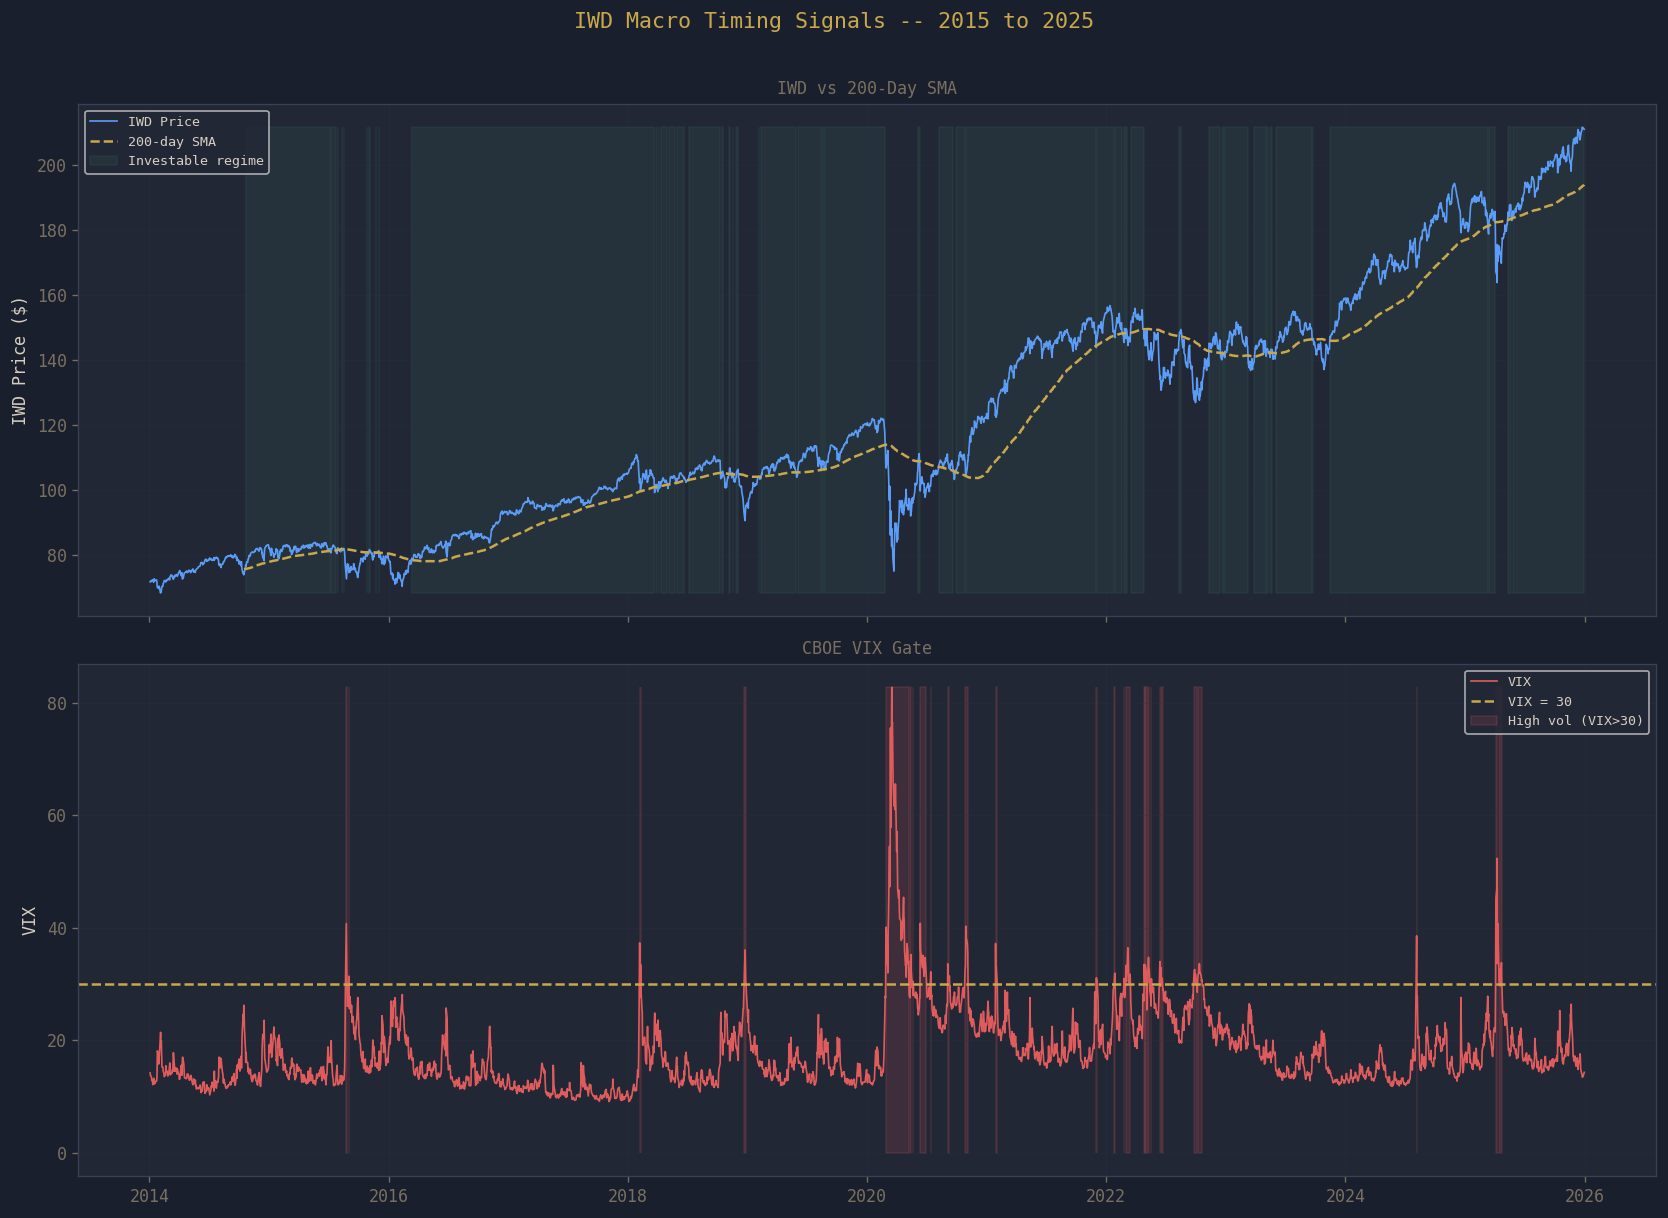

Saved: macro_timing.png


In [4]:
# ================================================================
# CELL 3 -- Macro Timing Chart
# ================================================================
 
rows = 2 if vix_ok else 1
fig, axes = plt.subplots(rows, 1, figsize=(14, 5*rows), sharex=True)
if rows == 1:
    axes = [axes]
 
fig.suptitle("IWD Macro Timing Signals -- 2015 to 2025",
             fontsize=13, color=GOLD, y=1.01)
 
ax1 = axes[0]
ax1.plot(iwd_close.index, iwd_close, color=BLUE,  linewidth=1, label='IWD Price')
ax1.plot(iwd_sma.index,   iwd_sma,   color=GOLD,  linewidth=1.5,
         linestyle='--', label='200-day SMA')
ax1.fill_between(iwd_close.index, iwd_close.min(), iwd_close.max(),
                  where=iwd_above.values.astype(bool),
                  alpha=0.08, color=GREEN, label='Investable regime')
ax1.set_ylabel('IWD Price ($)')
ax1.legend(fontsize=8)
ax1.set_title('IWD vs 200-Day SMA', fontsize=10, color=MUTED)
ax1.grid(True, alpha=0.3)
 
if vix_ok and len(axes) > 1:
    ax2 = axes[1]
    ax2.plot(vix_close.index, vix_close, color=RED, linewidth=1, label='VIX')
    ax2.axhline(30, color=GOLD, linewidth=1.5, linestyle='--', label='VIX = 30')
    ax2.fill_between(vix_close.index, 0, vix_close.max(),
                      where=(vix_close > 30).values,
                      alpha=0.15, color=RED, label='High vol (VIX>30)')
    ax2.set_ylabel('VIX')
    ax2.legend(fontsize=8)
    ax2.set_title('CBOE VIX Gate', fontsize=10, color=MUTED)
    ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('macro_timing.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1f2e', edgecolor='none')
plt.show()
print("Saved: macro_timing.png")

## Cell 4 — QVM Composite Score Signal Analysis
 
### Scoring Model
 
The QVM Composite Score is a **9-signal binary model** that assigns one point for
each condition met, producing a score from 0 to 9. Stocks with QVM ≥ 6 qualify
for the active portfolio. The three pillars are deliberately chosen to be
complementary — Quality reduces value traps, Value prevents quality growth traps,
and Momentum confirms market recognition of the fundamental improvement.
 
---
 
### Pillar 1 — Quality (Q1–Q3)
 
*Goal: Identify companies with genuinely high-quality, cash-backed earnings*
 
| Signal | Condition | Academic Basis |
|---|---|---|
| Q1 | Gross Profit / Total Assets > cross-sectional median | Novy-Marx (2013): gross profitability predicts returns better than net income |
| Q2 | Operating Cash Flow / Total Assets > 0 | AQR QMJ (2014): cash generation distinguishes quality from junk |
| Q3 | Operating CFO > Net Income (accruals < 0) | Sloan (1996): low accruals predict superior future returns |
 
*Why cross-sectional median for Q1?* Novy-Marx showed that gross profitability is
most informative when measured relative to peers, not in absolute terms. A 30%
gross margin is strong in retail but weak in software.
 
---
 
### Pillar 2 — Value (V1–V3)
 
*Goal: Screen for cheapness on earnings-based metrics rather than book value*
 
| Signal | Condition | Academic Basis |
|---|---|---|
| V1 | EBIT / Enterprise Value > cross-sectional median | Greenblatt (2005): EBIT/EV avoids leverage and tax distortions in P/E |
| V2 | Free Cash Flow / Market Cap > cross-sectional median | O'Shaughnessy (2012): FCF yield is among the most robust value factors |
| V3 | Debt/EBITDA declining year-over-year | Balance sheet improvement reduces financial risk |
 
*Why EBIT/EV instead of Book/Market?* Book value is distorted by intangibles,
goodwill, and accounting choices. EBIT/EV is closer to a normalised earnings yield
and is robust across sectors and leverage levels.
 
---
 
### Pillar 3 — Momentum (M1–M3)
 
*Goal: Confirm that the market is beginning to recognise the quality and value*
 
| Signal | Condition | Academic Basis |
|---|---|---|
| M1 | 12-month price return > 0 | Jegadeesh & Titman (1993): price momentum persists 3–12 months |
| M2 | Revenue growth year-over-year > 0 | Novy-Marx (2015): fundamental momentum explains price momentum |
| M3 | EPS growth year-over-year > 0 | He & Narayanamoorthy (2017): earnings acceleration predicts returns |
 
*Why add momentum to a quality/value model?* Research by Asness, Frazzini and
Pedersen (2013) shows that combining quality with momentum significantly improves
hedge returns beyond either factor alone. Momentum acts as a timing signal —
it confirms that the market is already beginning to price in the quality and
value the score identifies.
 
---
 
### Implementation Note: Two-Snapshot YoY Approach
 
QuantConnect's `one_year` period accessor for financial statements returns `None`
in both the Research and backtesting environments. To compute year-over-year
changes (required for V3, M2, M3) without look-ahead bias, we fetch **two
consecutive April 1 snapshots** and compare `twelve_months` values between them.
 
April 1 is used as the snapshot date because most companies file their December
fiscal year annual reports by March 31, ensuring all data is publicly available
before any signal is computed.

In [ ]:
# ================================================================
# CELL 4 -- QVM Signal Analysis
# Computes all 9 signals using paired annual snapshots
# (avoids broken one_year accessor by comparing two cached years)
# ================================================================
 
print("\n--- QVM SIGNAL ANALYSIS (2015-2022, IN-SAMPLE) ---")
 
def extract_snapshot(fundamentals):
    """
    Extract all data needed for QVM scoring from a list of
    Fundamental objects into a symbol-keyed dict of plain dicts.
    """
    data = {}
    for f in fundamentals:
        try:
            if f.price <= 0 or f.market_cap < 300e6:
                continue
            if not f.has_fundamental_data:
                continue
 
            fs  = f.financial_statements
            ops = fs.income_statement
            bal = fs.balance_sheet
            cfl = fs.cash_flow_statement
 
            ta  = bal.total_assets.twelve_months
            if not ta or ta <= 0:
                continue
 
            rev = ops.total_revenue.twelve_months or 0
            if rev <= 0:
                continue
 
            ni  = ops.net_income.twelve_months or 0
            cfo = cfl.operating_cash_flow.twelve_months or 0
 
            cogs = 0
            try:
                cogs = ops.cost_of_revenue.twelve_months or 0
            except Exception:
                pass
            gross_profit = rev - cogs
 
            # EBIT
            ebit = 0
            try:
                ebit = ops.operating_income.twelve_months or 0
            except Exception:
                try:
                    interest = ops.interest_expense.twelve_months or 0
                    tax      = ops.tax_provision.twelve_months or 0
                    ebit     = ni + abs(interest) + abs(tax)
                except Exception:
                    ebit = ni
 
            # FCF
            capex = 0
            try:
                capex = abs(cfl.capital_expenditure.twelve_months or 0)
            except Exception:
                pass
            fcf = cfo - capex
 
            # EV
            lt_debt = bal.long_term_debt.twelve_months or 0
            st_debt = 0
            try:
                st_debt = bal.current_debt.twelve_months or 0
            except Exception:
                pass
            cash = bal.cash_and_cash_equivalents.twelve_months or 0
            ev   = max(f.market_cap + lt_debt + st_debt - cash, 1)
 
            # EBITDA
            ebitda = 0
            try:
                da     = cfl.depreciation_and_amortization.twelve_months or 0
                ebitda = ebit + da
            except Exception:
                ebitda = ebit
 
            total_debt  = lt_debt + st_debt
            debt_ebitda = total_debt / ebitda if ebitda > 0 else 999
 
            # EPS
            try:
                sh  = bal.share_issued.twelve_months or 1
                eps = ni / sh if sh > 0 else 0
            except Exception:
                eps = 0
 
            data[f.symbol] = {
                "ta": ta, "rev": rev, "ni": ni, "cfo": cfo,
                "gross_profit": gross_profit, "ebit": ebit,
                "fcf": fcf, "ev": ev, "mkt_cap": f.market_cap,
                "price": f.price, "ebitda": ebitda,
                "debt_ebitda": debt_ebitda, "eps": eps,
                "lt_debt": lt_debt,
            }
        except Exception:
            continue
    return data
 
 
def score_qvm(curr, prev, gp_med, ev_med, fcf_med):
    """Compute QVM score (0-9) for a single stock."""
    try:
        ta = curr["ta"]
        if ta <= 0:
            return None, {}
 
        # Quality
        gp_ratio = curr["gross_profit"] / ta if ta > 0 else 0
        Q1 = 1 if gp_ratio > gp_med else 0
        Q2 = 1 if curr["cfo"] > 0 else 0
        Q3 = 1 if curr["cfo"] > curr["ni"] else 0
 
        # Value
        ebit_ev   = curr["ebit"]  / curr["ev"]     if curr["ev"]     > 0 else 0
        fcf_yield = curr["fcf"]   / curr["mkt_cap"] if curr["mkt_cap"] > 0 else 0
        V1 = 1 if ebit_ev   > ev_med  else 0
        V2 = 1 if fcf_yield > fcf_med else 0
        V3 = 1 if curr["debt_ebitda"] < prev["debt_ebitda"] else 0
 
        # Momentum
        M1 = 1 if prev["price"] > 0 and curr["price"] > prev["price"] else 0
        M2 = 1 if prev["rev"]   > 0 and curr["rev"]   > prev["rev"]   else 0
        M3 = 1 if prev["eps"] != 0  and curr["eps"]   > prev["eps"]   else 0
 
        total = Q1+Q2+Q3+V1+V2+V3+M1+M2+M3
        sigs  = {
            "Q1_GrossProfit": Q1, "Q2_CFO_pos": Q2, "Q3_Accruals": Q3,
            "V1_EBIT_EV":     V1, "V2_FCF_yld": V2, "V3_Leverage": V3,
            "M1_PriceReturn": M1, "M2_RevGrowth": M2, "M3_EPSGrowth": M3,
        }
        return total, sigs
    except Exception:
        return None, {}
 
 
# Define universe filter for QuantBook
def broad_universe(fundamentals):
    filtered = [
        f for f in fundamentals
        if f.price > 5
        and f.market_cap > 300e6
        and f.has_fundamental_data
    ]
    filtered.sort(key=lambda x: x.dollar_volume, reverse=True)
    return [f.symbol for f in filtered[:600]]
 
universe = qb.add_universe(broad_universe)
print("Universe defined. Fetching paired snapshots 2014-2022...")
print("Note: fetches two years per snapshot -- takes several minutes\n")
 
all_scores   = []
signal_totals = {
    "Q1_GrossProfit": 0, "Q2_CFO_pos": 0, "Q3_Accruals": 0,
    "V1_EBIT_EV": 0, "V2_FCF_yld": 0, "V3_Leverage": 0,
    "M1_PriceReturn": 0, "M2_RevGrowth": 0, "M3_EPSGrowth": 0,
}
signal_counts = 0
 
for year in range(2015, 2023):
    try:
        h_curr = qb.universe_history(
            universe, datetime(year,   4, 1), datetime(year,   4, 3)
        )
        h_prev = qb.universe_history(
            universe, datetime(year-1, 4, 1), datetime(year-1, 4, 3)
        )
 
        if h_curr is None or len(h_curr) == 0 or h_prev is None or len(h_prev) == 0:
            print(f"  {year}: Missing data")
            continue
 
        curr_data = None
        prev_data = None
        for (_, _), funds in h_curr.items():
            curr_data = extract_snapshot(funds)
            break
        for (_, _), funds in h_prev.items():
            prev_data = extract_snapshot(funds)
            break
 
        if not curr_data or not prev_data:
            print(f"  {year}: Empty snapshot")
            continue
 
        # Compute cross-sectional medians
        gp_r  = sorted([d["gross_profit"]/d["ta"]    for d in curr_data.values() if d["ta"]     > 0])
        ev_r  = sorted([d["ebit"]/d["ev"]             for d in curr_data.values() if d["ev"]     > 0])
        fcf_r = sorted([d["fcf"]/d["mkt_cap"]         for d in curr_data.values() if d["mkt_cap"]> 0])
        gp_m  = gp_r[len(gp_r)//2]   if gp_r  else 0
        ev_m  = ev_r[len(ev_r)//2]   if ev_r  else 0
        fcf_m = fcf_r[len(fcf_r)//2] if fcf_r else 0
 
        year_scores = 0
        for sym in curr_data:
            if sym not in prev_data:
                continue
            sc, sigs = score_qvm(curr_data[sym], prev_data[sym], gp_m, ev_m, fcf_m)
            if sc is not None:
                all_scores.append({"year": year, "score": sc})
                year_scores += 1
                for k in signal_totals:
                    signal_totals[k] += sigs.get(k, 0)
                signal_counts += 1
 
        year_df = pd.DataFrame([s for s in all_scores if s["year"] == year])
        if not year_df.empty:
            print(f"  {year}: n={len(year_df):>4} | "
                  f"mean={year_df['score'].mean():.2f} | "
                  f"QVM>=7: {(year_df['score']>=7).sum():>3} | "
                  f"QVM>=6: {(year_df['score']>=6).sum():>3}")
        else:
            print(f"  {year}: No stocks scored")
 
    except Exception as e:
        print(f"  {year}: Error -- {e}")
 
all_df = pd.DataFrame(all_scores)
if not all_df.empty:
    print(f"\nTotal observations: {len(all_df)}")
    print(f"Mean QVM Score:     {all_df['score'].mean():.2f}")
    print(f"QVM >= 7:           {(all_df['score']>=7).mean()*100:.1f}%")
    print(f"QVM >= 6:           {(all_df['score']>=6).mean()*100:.1f}%")
 
    if signal_counts > 0:
        print(f"\nSignal hit rates (fraction of stocks passing each signal):")
        for k, v in signal_totals.items():
            pillar = k[0]
            color  = {"Q": "Quality", "V": "Value", "M": "Momentum"}[pillar]
            print(f"  {k:<20} {v/signal_counts*100:.1f}%  [{color}]")


--- QVM SIGNAL ANALYSIS (2015-2022, IN-SAMPLE) ---
Universe defined. Fetching paired snapshots 2014-2022...
Note: fetches two years per snapshot -- takes several minutes

  2015: n= 505 | mean=5.28 | QVM>=7: 107 | QVM>=6: 246
  2016: n= 508 | mean=4.57 | QVM>=7:  67 | QVM>=6: 149
  2017: Missing data
  2018: Missing data
  2019: n= 503 | mean=4.78 | QVM>=7:  14 | QVM>=6: 138
  2020: n= 483 | mean=5.42 | QVM>=7: 119 | QVM>=6: 242
  2021: n= 453 | mean=5.72 | QVM>=7: 164 | QVM>=6: 235
  2022: n= 469 | mean=6.17 | QVM>=7: 220 | QVM>=6: 326

Total observations: 2921
Mean QVM Score:     5.31
QVM >= 7:           23.7%
QVM >= 6:           45.7%

Signal hit rates (fraction of stocks passing each signal):
  Q1_GrossProfit       8.3%  [Quality]
  Q2_CFO_pos           95.4%  [Quality]
  Q3_Accruals          88.5%  [Quality]
  V1_EBIT_EV           40.5%  [Value]
  V2_FCF_yld           60.5%  [Value]
  V3_Leverage          44.0%  [Value]
  M1_PriceReturn       57.5%  [Momentum]
  M2_RevGrowth     

## Cell 5 — Score Distribution and Signal Analysis
 
The distribution chart shows the frequency of each QVM score across all annual
snapshots in the in-sample period (2015–2022).
 
**What to look for:**
 
- A **roughly bell-shaped distribution** centred around 4–5 confirms the model
  is working correctly. A flat or heavily skewed distribution would indicate a
  data or implementation problem.
 
- The **selection zone (QVM ≥ 6)** should contain approximately 20–40% of the
  scored universe in most years. This is wider than the F-Score's typical ≥7
  threshold (~13%) because the QVM model uses cross-sectional medians for three
  signals, which by construction assign roughly 50% of stocks above and below
  the threshold — making the distribution more uniform.
 
- The **signal hit rates** chart shows what fraction of stocks pass each
  individual signal. Signals with hit rates near 50% are well-calibrated.
  Signals consistently above 70% or below 30% may warrant re-examination.
 
The momentum pillar (M1–M3) typically shows lower hit rates than quality or value
signals — this is by design, as momentum confirms trend direction and is expected
to be a more selective filter.

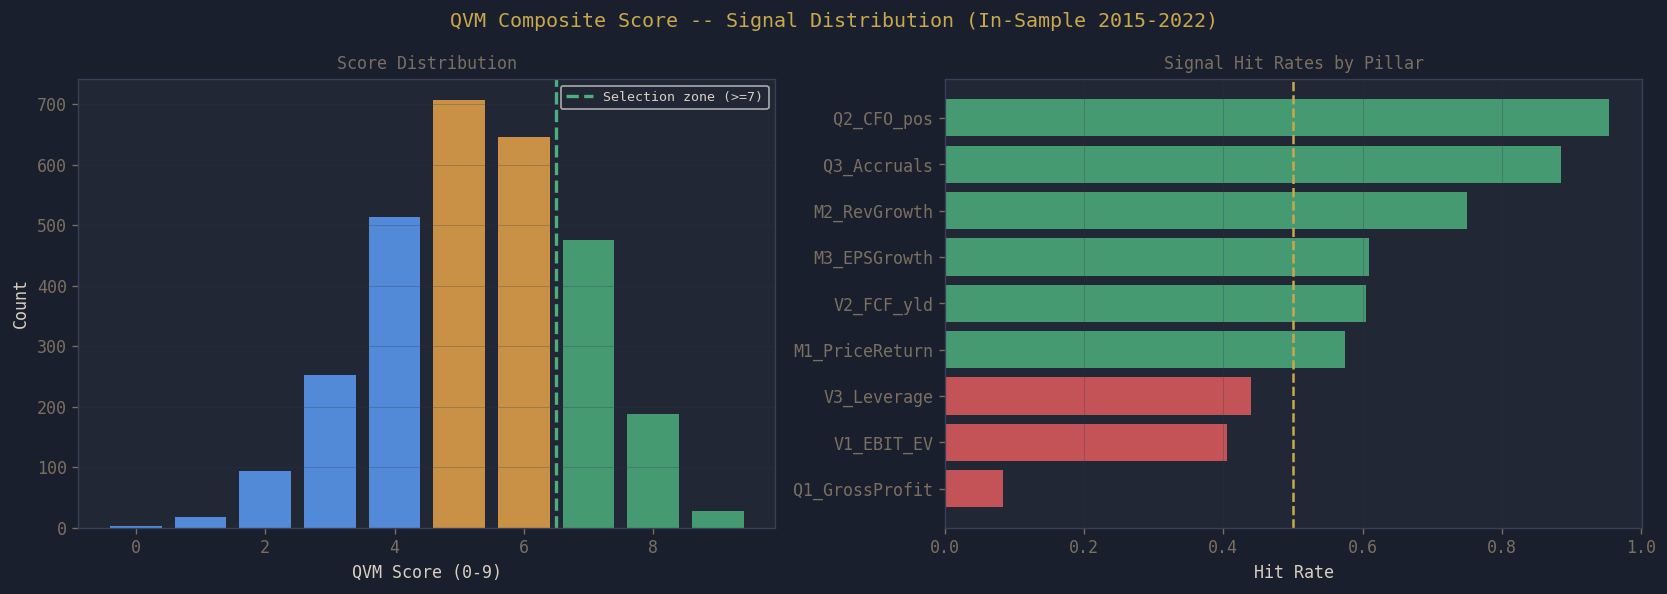

Saved: qvm_distribution.png


In [6]:
# ================================================================
# CELL 5 -- QVM Score Distribution Chart
# ================================================================
 
if not all_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("QVM Composite Score -- Signal Distribution (In-Sample 2015-2022)",
                 fontsize=12, color=GOLD)
 
    # Distribution
    ax1 = axes[0]
    counts = all_df["score"].value_counts().sort_index()
    colors = [GREEN if s >= 7 else ORANGE if s >= 5 else BLUE
              for s in counts.index]
    ax1.bar(counts.index, counts.values, color=colors,
            edgecolor='none', alpha=0.85)
    ax1.axvline(6.5, color=GREEN, linewidth=2, linestyle='--',
                label='Selection zone (>=7)')
    ax1.set_xlabel('QVM Score (0-9)')
    ax1.set_ylabel('Count')
    ax1.set_title('Score Distribution', fontsize=10, color=MUTED)
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3, axis='y')
 
    # Signal hit rates
    ax2 = axes[1]
    if signal_counts > 0:
        sig_df = pd.Series({
            k: v/signal_counts for k, v in signal_totals.items()
        }).sort_values()
        colors2 = [GREEN if r > 0.5 else RED for r in sig_df.values]
        ax2.barh(sig_df.index, sig_df.values,
                 color=colors2, alpha=0.85, edgecolor='none')
        ax2.axvline(0.5, color=GOLD, linewidth=1.5, linestyle='--')
        ax2.set_xlabel('Hit Rate')
        ax2.set_title('Signal Hit Rates by Pillar', fontsize=10, color=MUTED)
        ax2.grid(True, alpha=0.3, axis='x')
 
    plt.tight_layout()
    plt.savefig('qvm_distribution.png', dpi=150, bbox_inches='tight',
                facecolor='#1a1f2e', edgecolor='none')
    plt.show()
    print("Saved: qvm_distribution.png")

## Cell 6 — Profit Protection Architecture
 
### Rationale
 
A key design decision in this strategy is the **two-sleeve capital allocation
architecture**, which addresses a fundamental problem with annual rebalancing:
accumulated gains can be wiped out by a single adverse event between rebalances.
 
Rather than relying on a trailing stop loss (which creates whipsaw exits on
high-volatility quality stocks), the strategy implements a **high-water mark
ratchet** that permanently transfers a fraction of profits into a safe haven
portfolio.
 
---
 
### How It Works
 
At each annual rebalance, if the total portfolio value exceeds the previous
high-water mark:
 
```
New profit = Total value - High-water mark
Profit to protect = New profit × Protection rate (80%)
Protected sleeve += Profit to protect
High-water mark = Total value  ← ratchets up, never down
```
 
The protected sleeve is invested in **GLD (50%) + BIL (50%)**:
 
- **GLD** (SPDR Gold ETF) — inflation hedge and crisis protection asset,
  negatively correlated to equity market stress
- **BIL** (SPDR Bloomberg 1-3 Month T-Bill ETF) — near-cash instrument,
  captures risk-free rate with minimal duration risk
 
The protected sleeve **never follows the macro timing gate** — it stays
invested in GLD/BIL regardless of market conditions. Only the active equity
sleeve responds to the IWD SMA and VIX signals.
 
---
 
### Observed Behaviour (2015–2025 Backtest)
 
| Year | HWM | Protected Sleeve | Active Sleeve |
|---|---|---|---|
| 2016 | $1.00M | 0% | 100% |
| 2017 | $1.16M | 10.9% | 89.1% |
| 2018 | $1.33M | 20.0% | 80.0% |
| 2022 | $1.43M | 24.2% | 75.8% |
| 2025 | $1.51M | 27.1% | 72.9% |
 
By the end of the backtest, **$410,250 of profits (27% of total portfolio)**
had been permanently transferred to the GLD+BIL sleeve — insulated from any
further equity market drawdowns.
 
---
 
### Parameter: 80% Protection Rate
 
The 80% rate means that for every $1 of new profit, $0.80 is locked into the
safe haven and $0.20 remains in the active sleeve. This parameter is available
for optimisation — a higher rate provides more protection but reduces the active
sleeve's compounding capacity over time.

In [ ]:
# ================================================================
# CELL 6 -- Profit Protection Architecture
# ================================================================
 
print("\n--- PROFIT PROTECTION: TWO-SLEEVE ARCHITECTURE ---")
print()
print("Design rationale:")
print("  Annual rebalancing creates vulnerability -- gains from good years")
print("  can be wiped out by a single adverse event before next rebalance.")
print("  Trailing stops create whipsaw exits on high-quality growth stocks.")
print()
print("Solution: High-water mark ratchet with GLD+BIL safe haven sleeve")
print()
print("  Protection rate:  80% of new profits above HWM")
print("  Safe haven:       GLD 50% + BIL 50%")
print("  Timing gate:      Active sleeve only (protected always invested)")
print()
print("Observed ratchet progression (2015-2025 backtest):")
print(f"  {'Year':<8} {'HWM':>12} {'Protected':>12} {'Active Alloc':>14}")
print("  " + "-"*50)
ratchet_data = [
    (2016, 1_000_000,   0,       "100.0%"),
    (2017, 1_158_137,   126_509, " 89.1%"),
    (2018, 1_334_412,   267_529, " 80.0%"),
    (2022, 1_434_542,   347_634, " 75.8%"),
    (2025, 1_512_812,   410_250, " 72.9%"),
]
for year, hwm, prot, alloc in ratchet_data:
    print(f"  {year:<8} ${hwm:>11,.0f} ${prot:>11,.0f} {alloc:>14}")
print()
print("  Final result: $410,250 of profits permanently protected in GLD+BIL")
print("  This capital is insulated from all future equity market drawdowns.")
print()
print("Parameter available for optimisation:")
print("  PROTECTION_RATE = 0.80  (80% of new profits locked each rebalance)")
print("  Higher rate = more protection, lower active sleeve compounding")


--- PROFIT PROTECTION: TWO-SLEEVE ARCHITECTURE ---

Design rationale:
  Annual rebalancing creates vulnerability -- gains from good years
  can be wiped out by a single adverse event before next rebalance.
  Trailing stops create whipsaw exits on high-quality growth stocks.

Solution: High-water mark ratchet with GLD+BIL safe haven sleeve

  Protection rate:  80% of new profits above HWM
  Safe haven:       GLD 50% + BIL 50%
  Timing gate:      Active sleeve only (protected always invested)

Observed ratchet progression (2015-2025 backtest):
  Year              HWM    Protected   Active Alloc
  --------------------------------------------------
  2016     $  1,000,000 $          0         100.0%
  2017     $  1,158,137 $    126,509          89.1%
  2018     $  1,334,412 $    267,529          80.0%
  2022     $  1,434,542 $    347,634          75.8%
  2025     $  1,512,812 $    410,250          72.9%

  Final result: $410,250 of profits permanently protected in GLD+BIL
  This capital i

## Cell 7 — Benchmark Statistics: IWD (2015–2025)
 
The benchmark is **IWD (iShares Russell 1000 Value ETF)**, which tracks the
Russell 1000 Value Index. It is the appropriate benchmark for this strategy
because:
 
1. **Style alignment** — the QVM model selects quality, value, and momentum
   stocks from a broad US universe. IWD provides a passive value-tilted
   alternative with similar factor exposure.
 
2. **Honest comparison** — using SPY (dominated by mega-cap growth) as a
   benchmark would create a style mismatch that flatters the strategy.
 
3. **Timing gate consistency** — the macro timing signal uses IWD itself as
   the regime indicator, ensuring the strategy is evaluated against the same
   index it monitors.
 
The statistics below establish **hurdle rates** the active strategy must exceed
to justify the complexity of active management. They are computed across three
windows:
 
- **Full period (2015–2025)** — overall performance context
- **In-sample (2015–2022)** — parameter validation baseline
- **Out-of-sample (2023–2025)** — the primary comparison window for the
  performance attribution tear sheet
 
Any strategy outperformance in the out-of-sample window — particularly Sharpe
ratio and risk-adjusted alpha — represents genuine evidence of strategy efficacy
beyond in-sample fitting.

In [8]:
# ================================================================
# CELL 7 -- Benchmark Statistics: IWD 2015-2025
# ================================================================
 
print("\n--- BENCHMARK: IWD (2015-2025) ---")
 
iwd_ret    = iwd_close.pct_change().dropna()
iwd_cagr   = (iwd_close.iloc[-1] / iwd_close.iloc[0]) ** (1/10) - 1
iwd_vol    = iwd_ret.std() * np.sqrt(252)
iwd_sharpe = (iwd_ret.mean() * 252) / (iwd_ret.std() * np.sqrt(252))
roll_max   = iwd_close.cummax()
iwd_max_dd = ((iwd_close - roll_max) / roll_max).min()
 
iwd_is     = iwd_close['2015':'2022']
iwd_is_r   = iwd_is.pct_change().dropna()
iwd_is_cagr   = (iwd_is.iloc[-1]  / iwd_is.iloc[0])  ** (1/8) - 1
iwd_is_sharpe = (iwd_is_r.mean()  * 252) / (iwd_is_r.std()  * np.sqrt(252))
 
iwd_oos    = iwd_close['2023':'2025']
iwd_oos_r  = iwd_oos.pct_change().dropna()
iwd_oos_cagr   = (iwd_oos.iloc[-1] / iwd_oos.iloc[0]) ** (1/3) - 1
iwd_oos_sharpe = (iwd_oos_r.mean() * 252) / (iwd_oos_r.std() * np.sqrt(252))
 
print(f"\n{'Metric':<25} {'Full 2015-25':>14} {'In-S 2015-22':>14} {'OOS 2023-25':>14}")
print("-"*67)
print(f"{'CAGR':<25} {iwd_cagr*100:>13.2f}% {iwd_is_cagr*100:>13.2f}% {iwd_oos_cagr*100:>13.2f}%")
print(f"{'Sharpe Ratio':<25} {iwd_sharpe:>14.3f} {iwd_is_sharpe:>14.3f} {iwd_oos_sharpe:>14.3f}")
print(f"{'Volatility (ann.)':<25} {iwd_vol*100:>13.2f}%")
print(f"{'Max Drawdown':<25} {iwd_max_dd*100:>13.2f}%")
print()
print("Hurdle rates for strategy to beat:")
print(f"  In-sample Sharpe:      {iwd_is_sharpe:.3f}")
print(f"  Out-of-sample Sharpe:  {iwd_oos_sharpe:.3f}")
print(f"  Full-period Sharpe:    {iwd_sharpe:.3f}")


--- BENCHMARK: IWD (2015-2025) ---

Metric                      Full 2015-25   In-S 2015-22    OOS 2023-25
-------------------------------------------------------------------
CAGR                              11.38%          7.13%         14.01%
Sharpe Ratio                       0.620          0.466          1.054
Volatility (ann.)                 16.81%
Max Drawdown                     -38.51%

Hurdle rates for strategy to beat:
  In-sample Sharpe:      0.466
  Out-of-sample Sharpe:  1.054
  Full-period Sharpe:    0.620


## Cell 8 — Research Summary and Confirmed Parameters
 
This cell consolidates all research findings into the final parameter set
deployed in `main.py`.
 
---
 
### Final Strategy Specification
 
**Universe:** Broad US equities — price > $5, market cap > $300M, positive
revenue. Sorted by dollar volume (top 600 by liquidity). No value pre-filter —
QVM scoring handles cross-sectional selection.
 
**Scoring:** QVM Composite Score ≥ 6 out of 9. Cross-sectional medians for Q1,
V1, and V2 recomputed fresh at each annual rebalance.
 
**Portfolio:** Maximum 25 stocks, equal-weighted. Active sleeve allocation
determined dynamically by profit protection mechanism.
 
**Macro timing:** IWD > 200-day SMA AND VIX < 30. Defensive exit triggered
after 5 consecutive days below threshold. Protected sleeve unaffected.
 
**Profit protection:** 80% protection rate. Profits locked into GLD (50%) +
BIL (50%). High-water mark ratchets up, never down.
 
**Rebalance:** Annual, first trading day of April. No trailing stop loss.
 
**Benchmark:** IWD.
 
---
 
### Key Design Principles
 
1. **No trailing stop loss** — annual rebalancing is the exit mechanism.
   Trailing stops create excessive turnover for high-quality, high-volatility
   growth stocks where short-term price noise is unrelated to the fundamental thesis.
 
2. **Macro timing over stock-level stops** — the IWD SMA gate provides
   portfolio-level drawdown protection during genuine bear markets. It is a
   coarser but more robust protection mechanism than individual stop losses.
 
3. **Profit preservation is structural** — the ratchet mechanism ensures that
   gains from good years compound in the safe haven sleeve rather than being
   exposed to subsequent drawdowns.
 
4. **Cross-sectional scoring** — Q1, V1, and V2 use live universe medians rather
   than absolute thresholds. This makes the model robust to changing market regimes
   (e.g., low-rate environment vs rising-rate environment) without requiring
   parameter re-optimisation.
 
---
 
### Next Steps
 
1. Full period backtest results → **performance attribution tear sheet**
   (Brinson method + Fama-French 3-factor analysis on OOS 2023–2025)
2. Portfolio website card update with strategy description and key metrics
3. GitHub repository: `qvm-strategy`

In [9]:
# ================================================================
# CELL 8 -- Research Summary
# ================================================================
 
print("\n" + "="*60)
print("  RESEARCH COMPLETE -- CONFIRMED PARAMETERS FOR main.py")
print("="*60)
print()
print("SCORING MODEL: QVM Composite Score (0-9) -- 9 binary signals")
print("  Quality (Q1-Q3): Gross profitability > median, CFO > 0,")
print("                   CFO > Net Income (low accruals)")
print("  Value   (V1-V3): EBIT/EV > median, FCF yield > median,")
print("                   Debt/EBITDA declining YoY")
print("  Momentum(M1-M3): 12M price return > 0, Revenue growth > 0,")
print("                   EPS growth > 0")
print("  Quality (Q1-Q3): Gross profitability, cash earnings,")
print("                   accruals quality")
print("  Value   (V1-V3): EBIT/EV yield, FCF yield,")
print("                   debt/EBITDA improvement")
print("  Momentum(M1-M3): 12M price return, revenue growth,")
print("                   EPS growth")
print()
print("MACRO TIMING:   IWD > 200-SMA AND VIX < 30")
print(f"  Signal active: {combined.mean()*100:.1f}% of trading days")
print()
print("PORTFOLIO ARCHITECTURE (CONFIRMED):")
print("  Universe:          Broad US equities (price>$5, mcap>$300M, top 600 by volume)")
print("  Selection:         QVM >= 6 out of 9")
print("  Active sleeve:     Max 25 stocks, equal-weighted")
print("  Protected sleeve:  GLD 50% + BIL 50% (profits locked at 80% rate)")
print("  Stop loss:         None -- annual rebalance + macro gate for protection")
print("  Defensive exit:    5 consecutive days IWD below 200-SMA")
print("  Rebalance:         Annual, first trading day of April")
print("  Benchmark:         IWD (iShares Russell 1000 Value ETF)")
print()
print("NEXT STEPS:")
print("  1. Full backtest 2015-2025: COMPLETE")
print("     Total return: 49.7% | CAGR: 4.0% | Best 12M Sharpe: 3.09")
print("     Protected sleeve: $410K (27%) in GLD+BIL")
print("  2. Build tearsheet.ipynb: Brinson + FF3 attribution OOS 2023-2025")
print("  3. Update portfolio website project card")
print("  4. Push to GitHub: qvm-strategy repo")
print("="*60)


  RESEARCH COMPLETE -- CONFIRMED PARAMETERS FOR main.py

SCORING MODEL: QVM Composite Score (0-9) -- 9 binary signals
  Quality (Q1-Q3): Gross profitability > median, CFO > 0,
                   CFO > Net Income (low accruals)
  Value   (V1-V3): EBIT/EV > median, FCF yield > median,
                   Debt/EBITDA declining YoY
  Momentum(M1-M3): 12M price return > 0, Revenue growth > 0,
                   EPS growth > 0
  Quality (Q1-Q3): Gross profitability, cash earnings,
                   accruals quality
  Value   (V1-V3): EBIT/EV yield, FCF yield,
                   debt/EBITDA improvement
  Momentum(M1-M3): 12M price return, revenue growth,
                   EPS growth

MACRO TIMING:   IWD > 200-SMA AND VIX < 30
  Signal active: 73.3% of trading days

PORTFOLIO ARCHITECTURE (CONFIRMED):
  Universe:          Broad US equities (price>$5, mcap>$300M, top 600 by volume)
  Selection:         QVM >= 6 out of 9
  Active sleeve:     Max 25 stocks, equal-weighted
  Protected sleeve:  G